## Let's visualize the betti numbers of Figure one

In [1]:
import graph_mph
import matplotlib.pyplot as plt
import numpy as np

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="firep",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    file_path="figure1_data.firep",
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

In [2]:
print(f"x coordinates: {bifi.get_x_coords()}")
print(f"y coordinates: {bifi.get_y_coords()}")

x coordinates: [1, 2, 3, 5, 6]
y coordinates: [1, 2, 3, 5, 6]


In [3]:
res

{'b_0': [(0, 2), (1, 0)],
 'b_1': [(2, 3), (3, 2)],
 'b_2': [(3, 3)],
 'b_0_1': [(3, 3), (4, 1), (4, 4)],
 'M': [(1, 1, -1), (2, 1, 1), (1, 2, -1), (2, 2, 1)]}

So the results are 
- `b_0`: $\beta_0(H_0)$
- `b_1`: $\beta_1(H_0)$
- `b_2`: $\beta_2(H_0)$
- `b_0_1`: $\beta_0(H_1)$
- `M`: minimal presentation--a list of triples (i, j, v) representing value v at at row i and column j, where i represents the ith element of `b_0` and j represents the jth element of `b_1` (1-indexed). 

Note here we represent the minimal presentation matrix in a different way from RIVET. 

If you call RIVET, then you will see 
```bash
$ rivet_console figure1_data_for_rivet.firep --minpre
x-grades(size: 5)
1
2
3
5
6

y-grades(size: 5)
1
2
3
5
6

MINIMAL PRESENTATION:
Number of rows:2
Row bigrades:
| (1,0) (0,2) |
Number of columns:2
Column bigrades:
| (3,2) (2,3) |
0 1 
0 1 
```
RIVET uses column sparse matrix to store the entries. Our results match with them. 

In [ ]:
def save_minimal_presentation_to_scc_file(minimal_presentation, file_path):
    """
    Save the minimal presentation to a SCC file.
    """


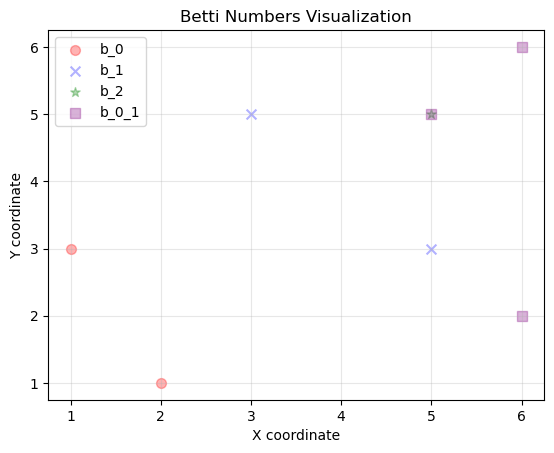

In [3]:
# Define shapes for different Betti numbers
shapes = {
    "b_0": "o",  # circle
    "b_1": "x",  # cross
    "b_2": "*",  # star
    "b_0_1": "s",  # square
}

colors = {
    "b_0": "red",
    "b_1": "blue",
    "b_2": "green",
    "b_0_1": "purple",
}

# Plot the betti numbers with different shapes and colors
for name in ["b_0", "b_1", "b_2", "b_0_1"]:
    betti_numbers = np.array(res[name])
    plt.scatter(
        betti_numbers[:, 0],
        betti_numbers[:, 1],
        c=colors[name],
        marker=shapes[name],
        s=50,
        alpha=0.3,
        label=name,
    )

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Betti Numbers Visualization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Ok, now let's try to visualize the minimal presentation. 

In [4]:
from graph_mph import convert_betti_numbers_to_2d_array

b0_arr = convert_betti_numbers_to_2d_array(res["b_0"], 7, 7)
b1_arr = convert_betti_numbers_to_2d_array(res["b_1"], 7, 7)
b2_arr = convert_betti_numbers_to_2d_array(res["b_2"], 7, 7)

In [5]:
b0_arr

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]], dtype=int32)

In [6]:
# More efficient implementation using numpy's cumsum
def compute_2d_prefix_sum(binary_matrix):
    """
    More efficient 2D prefix sum using numpy's cumsum function.

    Args:
        binary_matrix: 2D numpy array of 0s and 1s

    Returns:
        H: 2D numpy array where H[i,j] is the cumulative count
    """
    # First compute cumulative sum along rows (axis=1)
    row_cumsum = np.cumsum(binary_matrix, axis=1)

    # Then compute cumulative sum along columns (axis=0)
    H = np.cumsum(row_cumsum, axis=0)

    return H


In [7]:
presum_b0_arr = compute_2d_prefix_sum(b0_arr)
presum_b1_arr = compute_2d_prefix_sum(b1_arr)
presum_b2_arr = compute_2d_prefix_sum(b2_arr)
hilbert_matrix = presum_b0_arr - presum_b1_arr + presum_b2_arr
hilbert_matrix

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 1],
       [0, 1, 1, 2, 2, 2, 2],
       [0, 1, 1, 2, 2, 1, 1],
       [0, 1, 1, 2, 2, 1, 1],
       [0, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1]])

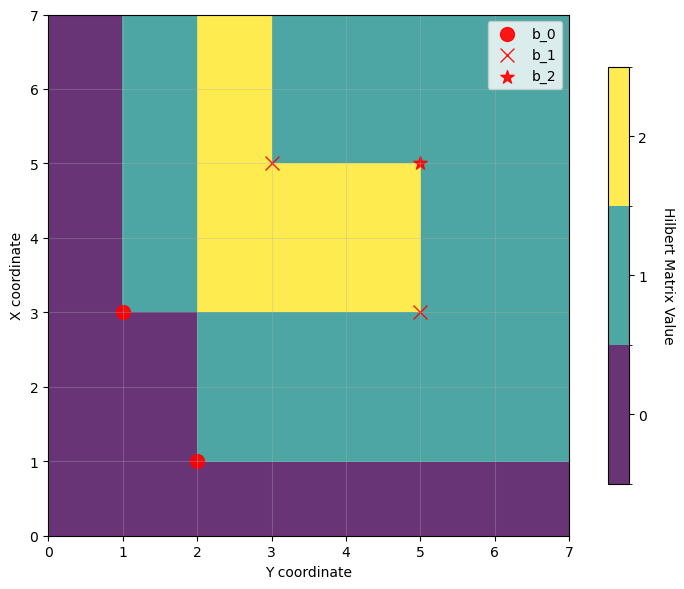

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

H = hilbert_matrix

# Create a figure with subplots
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Get unique integer values in the matrix for discrete colormap
unique_values = np.unique(H)
n_values = len(unique_values)

# Create discrete colormap
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, n_values))
discrete_cmap = ListedColormap(colors)

# Create boundaries for discrete colorbar
boundaries = np.arange(n_values + 1) - 0.5
norm = BoundaryNorm(boundaries, discrete_cmap.N)

# Left plot: Hilbert matrix with Betti numbers overlay
im = ax1.imshow(
    H.T,
    cmap=discrete_cmap,
    norm=norm,
    origin="lower",
    extent=[0, H.shape[1], 0, H.shape[0]],
    alpha=0.8,
)
# ax1.set_title("Hilbert Matrix with Betti Numbers Overlay")
ax1.set_xlabel("Y coordinate")
ax1.set_ylabel("X coordinate")

# Add discrete colorbar
cbar = plt.colorbar(im, ax=ax1, shrink=0.8, aspect=20, ticks=unique_values)
cbar.set_label("Hilbert Matrix Value", rotation=270, labelpad=20)

# Define shapes and colors for different Betti numbers
shapes = {
    "b_0": "o",  # circle
    "b_1": "x",  # cross
    "b_2": "*",  # star
    "b_0_1": "s",  # square
}

colors = {
    "b_0": "red",
    "b_1": "red",
    "b_2": "red",
    "b_0_1": "red",
}

# Overlay Betti numbers on the imshow
for name in ["b_0", "b_1", "b_2"]:
    if name in res and len(res[name]) > 0:
        betti_numbers = np.array(res[name])
        ax1.scatter(
            betti_numbers[:, 0],  # y-coordinate for scatter
            betti_numbers[:, 1],  # x-coordinate for scatter
            c=colors[name],
            marker=shapes[name],
            s=100,  # Larger size for better visibility
            alpha=0.9,
            label=name,
            linewidth=1,
        )

ax1.legend()
ax1.grid(True, alpha=0.3)
plt.savefig("Hilbert_matrix_with_betti_numbers_figure1.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [14]:
def plot_free_persistence_module(
    betti_numbers, grid_shape, label="Betti_0", marker="o"
):
    """
    Plot the free persistence module of the given betti numbers.

    Args:
        betti_numbers: list of betti numbers
        grid_shape: tuple of the shape of the grid (m, n)
    Returns:
        plt: the plot of the free persistence module
    """
    # Convert betti numbers to 2D array
    betti_numbers_grid_array = convert_betti_numbers_to_2d_array(
        betti_numbers, grid_shape[0], grid_shape[1]
    )

    # Compute the prefix sum of the betti numbers
    presum_betti_numbers_array = compute_2d_prefix_sum(betti_numbers_grid_array)

    # Plot both b0_arr rectangles and b_0 betti numbers in the same plot
    # fig, ax = plt.subplots(figsize=(4, 3))
    fig, ax = plt.subplots(figsize=(8, 6))  # for saving plot

    # Plot the b0_arr as rectangles with transparency
    im = ax.imshow(
        presum_betti_numbers_array.T,
        cmap="Blues",
        alpha=0.3,
        origin="lower",
        extent=[0, b0_arr.shape[1], 0, b0_arr.shape[0]],
    )

    # Add colorbar for the b0_arr
    cbar = plt.colorbar(
        im,
        ax=ax,
        shrink=0.8,
        ticks=np.arange(
            np.min(presum_betti_numbers_array), np.max(presum_betti_numbers_array) + 1
        ),
    )
    # cbar.set_label("b0_arr values", rotation=270, labelpad=15)

    # Now plot the betti numbers as scatter points
    ax.scatter(
        np.array(betti_numbers)[:, 0],
        np.array(betti_numbers)[:, 1],
        c="red",
        label=label,
        marker=marker,
        s=100,
        alpha=0.8,
        edgecolors="darkred",
        linewidth=2,
    )
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    # ax.set_title("beta_0")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Set axis limits to show the full range
    ax.set_xlim(-0.5, b0_arr.shape[1] - 0.5)
    ax.set_ylim(-0.5, b0_arr.shape[0] - 0.5)

    plt.tight_layout()
    # plt.savefig("b0_betti_numbers.pdf", dpi=300)
    # plt.show()
    return plt

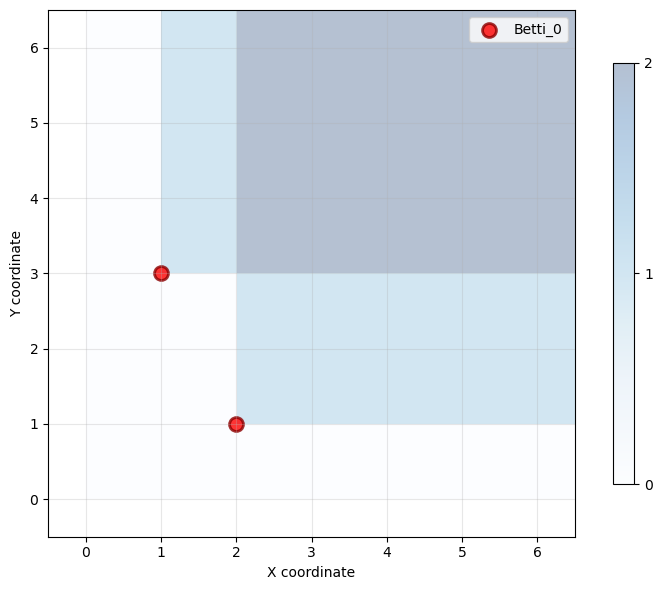

In [16]:
plt_betti_0_free_persistence_module = plot_free_persistence_module(res["b_0"], (7, 7))
plt.savefig("b0_betti_numbers.pdf", dpi=300)
plt.show()

/tmp/ipykernel_1248117/222081742.py:46: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


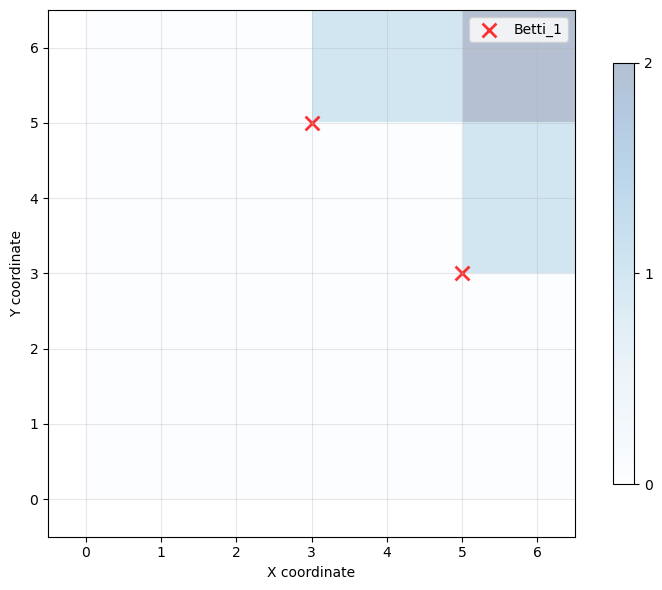

In [ ]:
plt_betti_0_free_persistence_module = plot_free_persistence_module(
    res["b_1"], (7, 7), label="Betti_1", marker="x"
)
plt.savefig("b1_betti_numbers.pdf", dpi=300)
plt.show()

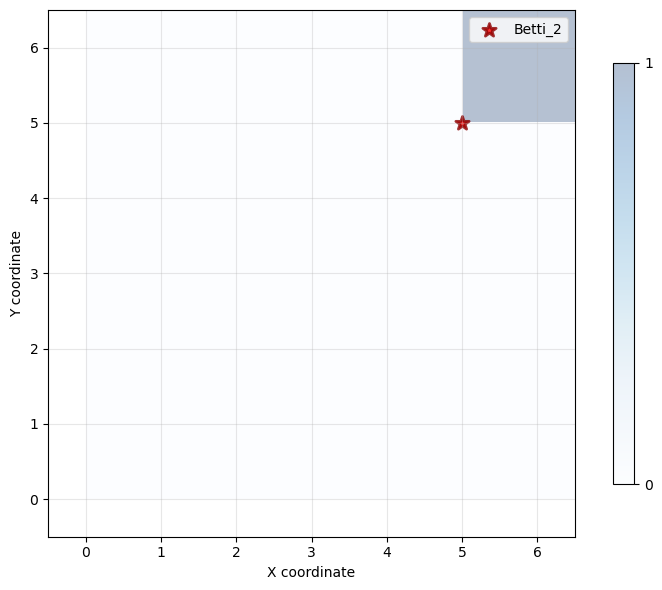

In [18]:
plt_betti_0_free_persistence_module = plot_free_persistence_module(
    res["b_2"], (7, 7), label="Betti_2", marker="*"
)
plt.savefig("b2_betti_numbers.pdf", dpi=300)
plt.show()